#**Iris Dataset Classification Analysis**
##**Course**: STQD6324 Data Management
##**Semester**: Semester 2 2025/2026

####This Notebook uses Spark MLlib to perform multi-class classification tasks on the classic Iris dataset, including data preprocessing, training and tuning of three classification models, and comparative analysis of model performance.

####This project aims to compare different Spark MLlib classification algorithms and identify the most suitable model for the Iris dataset through systematic hyperparameter tuning and performance evaluation.

##**1. Environment Preparation First**
####Confirm that PySpark is installed, and then import all the libraries you need at once.

In [34]:
!pip install pyspark -q

from sklearn.datasets import load_iris
import pandas as pd

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
)
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

print("All libraries have been imported.")

All libraries have been imported.


##**2. Start a Spark session**
####Run PySpark on Colab in local mode.

In [35]:
spark = SparkSession.builder \
    .appName("Iris_Classification") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark version：", spark.version)

Spark version： 4.0.2


##**3. Load the Iris dataset**

####The Iris dataset contains 150 records with 4 features (calyx length and width, petal length and width) and 3 categories (Setosa / Versicolor / Virginica).

####Here, the data is obtained using sklearn and then converted into a Spark DataFrame for subsequent processing using the Spark API.

In [36]:
# Use sklearn to get the data, saving you the trouble of manually downloading CSV files.
iris = load_iris()
pdf = pd.DataFrame(iris.data, columns=iris.feature_names)
pdf["label"] = iris.target

# Convert to Spark DataFrame
df = spark.createDataFrame(pdf)

print(f"Dataset size：{df.count()} rows，{len(df.columns)} columns")
print("Sample size of each category：")
df.groupBy("label").count().orderBy("label").show()

df.show(5)

Dataset size：150 rows，5 columns
Sample size of each category：
+-----+-----+
|label|count|
+-----+-----+
|    0|   50|
|    1|   50|
|    2|   50|
+-----+-----+

+-----------------+----------------+-----------------+----------------+-----+
|sepal length (cm)|sepal width (cm)|petal length (cm)|petal width (cm)|label|
+-----------------+----------------+-----------------+----------------+-----+
|              5.1|             3.5|              1.4|             0.2|    0|
|              4.9|             3.0|              1.4|             0.2|    0|
|              4.7|             3.2|              1.3|             0.2|    0|
|              4.6|             3.1|              1.5|             0.2|    0|
|              5.0|             3.6|              1.4|             0.2|    0|
+-----------------+----------------+-----------------+----------------+-----+
only showing top 5 rows


#### **Interpretation**
The Iris dataset was successfully loaded into a Spark DataFrame. Spark DataFrames provide distributed storage and efficient processing, making them suitable for scalable machine learning workflows.

## **4. Exploratory Data Analysis (EDA)**

Before building machine learning models, it is important to understand the characteristics and quality of the dataset.

This exploratory data analysis (EDA) aims to:

* Understand the dataset structure
* Check for missing values
* Examine class distribution
* Generate descriptive statistics
* Identify potential outliers

Performing EDA helps ensure that the dataset is suitable for machine learning and provides confidence in the reliability of subsequent analyses.


In [37]:
print("Number of Rows:", df.count())
print("Number of Columns:", len(df.columns))

print("\nColumn Names:")
print(df.columns)

Number of Rows: 150
Number of Columns: 5

Column Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'label']


#### **Interpretation**

The dataset contains three balanced iris species with four numerical features. No obvious data quality issues were observed, making it suitable for classification without extensive preprocessing.

### **4.1 Dataset Preview**

The first few observations are displayed below to verify that the dataset has been loaded correctly and to gain an initial understanding of its structure.


In [38]:
df.show(100)

+-----------------+----------------+-----------------+----------------+-----+
|sepal length (cm)|sepal width (cm)|petal length (cm)|petal width (cm)|label|
+-----------------+----------------+-----------------+----------------+-----+
|              5.1|             3.5|              1.4|             0.2|    0|
|              4.9|             3.0|              1.4|             0.2|    0|
|              4.7|             3.2|              1.3|             0.2|    0|
|              4.6|             3.1|              1.5|             0.2|    0|
|              5.0|             3.6|              1.4|             0.2|    0|
|              5.4|             3.9|              1.7|             0.4|    0|
|              4.6|             3.4|              1.4|             0.3|    0|
|              5.0|             3.4|              1.5|             0.2|    0|
|              4.4|             2.9|              1.4|             0.2|    0|
|              4.9|             3.1|              1.5|          

### **4.2 Missing Value Analysis**

Missing values can negatively affect model performance and lead to unreliable predictions.

Therefore, the dataset is examined to identify any null or missing values before proceeding with model development.


In [39]:
from pyspark.sql.functions import col,isnan,when,count

df.select([
    count(
        when(
            col(c).isNull() | isnan(c),
            c
        )
    ).alias(c)
    for c in df.columns[:-1]
]).show()

+-----------------+----------------+-----------------+----------------+
|sepal length (cm)|sepal width (cm)|petal length (cm)|petal width (cm)|
+-----------------+----------------+-----------------+----------------+
|                0|               0|                0|               0|
+-----------------+----------------+-----------------+----------------+



####**Interpretation**

The output shows that no missing values are present in any feature column.

Therefore, no imputation or missing value treatment is required.


### **4.3 Class Distribution Analysis**

Class distribution is examined to determine whether the dataset is balanced.

A balanced dataset ensures that machine learning models do not become biased toward any particular class.


In [40]:
df.groupBy("label").count().show()

+-----+-----+
|label|count|
+-----+-----+
|    0|   50|
|    1|   50|
|    2|   50|
+-----+-----+



### **4.4 Descriptive Statistics**

Descriptive statistics provide an overview of the central tendency and variability of each feature.

These statistics help identify unusual patterns and provide insight into the distribution of measurements across flower samples.


In [41]:
df.describe().show()

+-------+------------------+------------------+------------------+------------------+------------------+
|summary| sepal length (cm)|  sepal width (cm)| petal length (cm)|  petal width (cm)|             label|
+-------+------------------+------------------+------------------+------------------+------------------+
|  count|               150|               150|               150|               150|               150|
|   mean| 5.843333333333332|3.0573333333333337| 3.758000000000001|1.1993333333333331|               1.0|
| stddev|0.8280661279778628|0.4358662849366982|1.7652982332594664|0.7622376689603467|0.8192319205190403|
|    min|               4.3|               2.0|               1.0|               0.1|                 0|
|    max|               7.9|               4.4|               6.9|               2.5|                 2|
+-------+------------------+------------------+------------------+------------------+------------------+



### **4.5 Outlier Detection**

Outliers can influence model performance and potentially distort classification results.

Boxplots are used to visually inspect the presence of extreme observations within each feature.


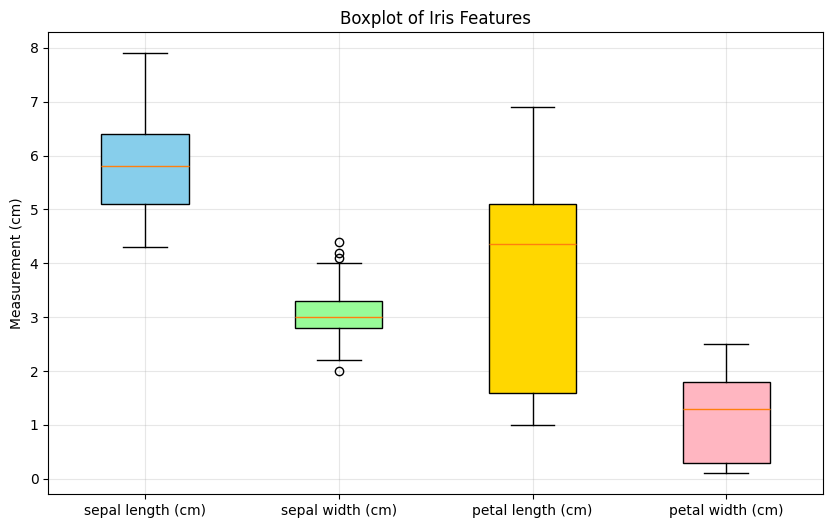

In [43]:
import matplotlib.pyplot as plt

pdf = df.toPandas()

features = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
]

fig, ax = plt.subplots(figsize=(10,6))

bp = ax.boxplot(
    [pdf[col] for col in features],
    tick_labels=features,  # Changed 'labels' to 'tick_labels'
    patch_artist=True
)

colors = [
    "#87CEEB",
    "#98FB98",
    "#FFD700",
    "#FFB6C1"
]

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.title("Boxplot of Iris Features")
plt.ylabel("Measurement (cm)")
plt.grid(True, alpha=0.3)
plt.show()

####**Feature Distribution by Species**

In addition to detecting potential outliers, it is important to examine how feature values vary across different Iris species.

Boxplots grouped by species provide a visual comparison of feature distributions and help identify variables that contribute most to species differentiation.

Understanding these patterns offers valuable insight into the classification task and supports the interpretation of model results.

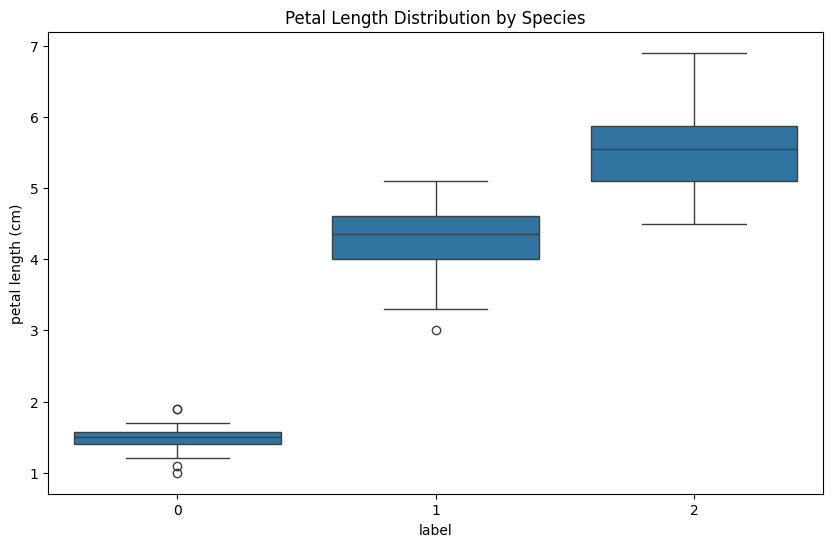

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

pdf = df.toPandas()

plt.figure(figsize=(10,6))

sns.boxplot(
    x='label',
    y='petal length (cm)',
    data=pdf
)

plt.title('Petal Length Distribution by Species')
plt.show()

####The boxplot shows that petal length differs substantially across species, indicating that this feature is highly informative for classification.

### **4.6 Pairwise Feature Relationships**

A pairplot is used to visualise the relationships among all numerical features while distinguishing observations according to Iris species.

This analysis helps identify feature separability, correlations between variables, and patterns that may influence classification performance.

By examining pairwise feature distributions before model development, we can gain valuable insight into which features are most useful for distinguishing different Iris species.


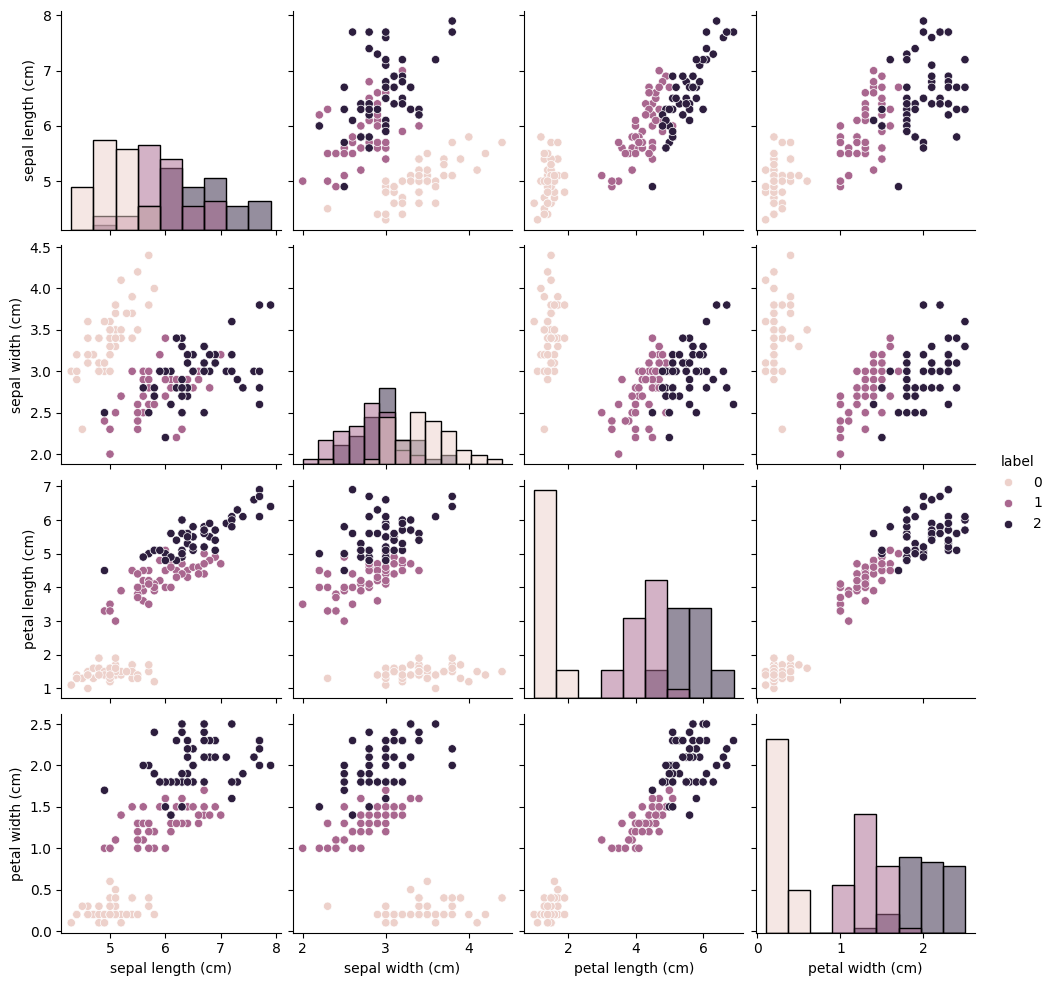

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

pdf = df.toPandas()

sns.pairplot(
    pdf,
    hue="label",
    diag_kind="hist"
)

plt.show()

#### **Interpretation**

The pairplot reveals distinct clustering patterns among the three Iris species.

Petal length and petal width exhibit clear separation between classes, indicating that these variables possess strong discriminatory power for classification. In contrast, sepal length and sepal width display greater overlap across species, suggesting that they are less effective as standalone predictors.

The visualisation also indicates that several feature pairs demonstrate positive relationships, particularly between petal length and petal width. These observations suggest that petal-related measurements are likely to play a significant role in distinguishing Iris species.

Overall, the dataset exhibits well-defined class boundaries, indicating that it is highly suitable for supervised classification tasks.


### **4.7 EDA Conclusion**

The exploratory data analysis confirms that the Iris dataset is clean, balanced, and appropriate for machine learning applications.

No missing values were detected, and no severe outliers were observed. The class distribution is perfectly balanced, reducing the risk of classification bias.

Visual analysis further demonstrates that petal-related features provide strong separation among species, suggesting that these variables will contribute significantly to classification performance.

Based on these findings, the dataset is considered suitable for model training, hyperparameter tuning, and performance evaluation.


## **5. Data Preprocessing**

####Machine learning algorithms in Spark MLlib require input features to be represented as a single vector.

####Therefore, the four numerical measurements are combined into a feature vector using the VectorAssembler transformer.

####The species labels are already encoded numerically, making them suitable for classification modelling.


Since all four features are already numerical and no missing values are detected, only VectorAssembler is required before model training. Feature scaling is not mandatory for this assignment because tree-based algorithms are insensitive to feature scales, while Logistic Regression can still perform well on the Iris dataset.


In [46]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "sepal length (cm)",
        "sepal width (cm)",
        "petal length (cm)",
        "petal width (cm)"
    ],
    outputCol="features"
)

iris_features = assembler.transform(df)

iris_features.select(
    "features",
    "label"
).show(20,False)

+-----------------+-----+
|features         |label|
+-----------------+-----+
|[5.1,3.5,1.4,0.2]|0    |
|[4.9,3.0,1.4,0.2]|0    |
|[4.7,3.2,1.3,0.2]|0    |
|[4.6,3.1,1.5,0.2]|0    |
|[5.0,3.6,1.4,0.2]|0    |
|[5.4,3.9,1.7,0.4]|0    |
|[4.6,3.4,1.4,0.3]|0    |
|[5.0,3.4,1.5,0.2]|0    |
|[4.4,2.9,1.4,0.2]|0    |
|[4.9,3.1,1.5,0.1]|0    |
|[5.4,3.7,1.5,0.2]|0    |
|[4.8,3.4,1.6,0.2]|0    |
|[4.8,3.0,1.4,0.1]|0    |
|[4.3,3.0,1.1,0.1]|0    |
|[5.8,4.0,1.2,0.2]|0    |
|[5.7,4.4,1.5,0.4]|0    |
|[5.4,3.9,1.3,0.4]|0    |
|[5.1,3.5,1.4,0.3]|0    |
|[5.7,3.8,1.7,0.3]|0    |
|[5.1,3.8,1.5,0.3]|0    |
+-----------------+-----+
only showing top 20 rows


#### **Interpretation**

Since all predictor variables are numerical and the dataset contains no missing values, only feature assembly is required before model training. Feature scaling is not essential for tree-based models such as Decision Tree and Random Forest, while Logistic Regression can still perform effectively on the Iris dataset without additional scaling.

## **6. Train-Test Split**

####The dataset is divided into training and testing subsets using a 70:30 ratio.

####The training dataset is used for model development and hyperparameter tuning, while the testing dataset is reserved for evaluating model generalisation performance on unseen data.


In [47]:
train, test = df.randomSplit([0.7, 0.3], seed=42)

print(f"training set：{train.count()} strips")
print(f"test set：{test.count()} strips")

train.show(5, truncate=False)
test.show(5, truncate=False)

training set：94 strips
test set：56 strips
+-----------------+----------------+-----------------+----------------+-----+
|sepal length (cm)|sepal width (cm)|petal length (cm)|petal width (cm)|label|
+-----------------+----------------+-----------------+----------------+-----+
|4.3              |3.0             |1.1              |0.1             |0    |
|4.4              |2.9             |1.4              |0.2             |0    |
|4.4              |3.2             |1.3              |0.2             |0    |
|4.5              |2.3             |1.3              |0.3             |0    |
|4.6              |3.1             |1.5              |0.2             |0    |
+-----------------+----------------+-----------------+----------------+-----+
only showing top 5 rows
+-----------------+----------------+-----------------+----------------+-----+
|sepal length (cm)|sepal width (cm)|petal length (cm)|petal width (cm)|label|
+-----------------+----------------+-----------------+----------------+-----

####**Interpretation**
Approximately 70% of the observations were used for model training, while the remaining 30% were reserved for unbiased model evaluation.

## **7. Evaluation Metrics**

Several evaluation metrics are employed to assess classification performance.

* Accuracy measures the proportion of correctly classified observations.
* Precision evaluates the proportion of positive predictions that are correct.
* Recall measures the ability of the model to identify all relevant observations.
* F1-score provides a balance between precision and recall.

Using multiple metrics offers a more comprehensive assessment of model effectiveness.


## **8. Define the evaluator.**
###All three models share the same evaluator object, which will also be used in cross-validation.

###The main evaluation metric is Accuracy first; F1, Precision, and Recall will be calculated separately during the final comparison.

In [48]:
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)
evaluator

MulticlassClassificationEvaluator_039f0a031bb8

#**9. Create models**

##**9.1 Model 1: Logistic Regression**
###Logistic regression is a linear classification model. It trains quickly, has strong interpretability, and is suitable as a baseline solution.

##**Tuning Parameters:**

- `regParam`: L2 regularization strength to prevent overfitting. Values `​​[0.01, 0.05, 0.1]` cover a range from weak to moderate regularization.

- `maxIter`: Maximum number of iterations. For small Iris datasets, 100 iterations are sufficient for convergence.

- Cross-validation folds: 5 folds (more folds for smaller datasets result in greater stability).

### **Hyperparameter Tuning**

- Hyperparameter tuning is performed using Grid Search combined with 5-fold Cross Validation.

- Grid Search evaluates multiple combinations of parameter values, while Cross Validation provides a reliable estimate of model performance by repeatedly partitioning the training data.

- This process helps identify the optimal model configuration and improves generalisation capability.

- Grid Search was applied to evaluate multiple combinations of hyperparameters, while five-fold Cross Validation was used to estimate model performance. This process helps identify the optimal parameter settings and improves model generalisation.


In [51]:
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    family="multinomial"   # Three-category classification requires the use of multinomial.
)

paramGrid_lr = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.01, 0.05, 0.1])
    .addGrid(lr.maxIter, [100])
    .build()
)

# Apply VectorAssembler to train and test sets
train_assembled = assembler.transform(train)
test_assembled = assembler.transform(test)

cv_lr = CrossValidator(
    estimator=lr,
    estimatorParamMaps=paramGrid_lr,
    evaluator=evaluator,
    numFolds=5,
    seed=42
)

print("train Logistic Regression...")
model_lr = cv_lr.fit(train_assembled)
pred_lr = model_lr.transform(test_assembled)

# Optimal hyperparameters
best_lr = model_lr.bestModel
print(f"optimal regParam：{best_lr._java_obj.getRegParam()}")

# Each indicator
acc_lr       = evaluator.evaluate(pred_lr)
f1_lr        = MulticlassClassificationEvaluator(metricName="f1").evaluate(pred_lr)
precision_lr = MulticlassClassificationEvaluator(metricName="weightedPrecision").evaluate(pred_lr)
recall_lr    = MulticlassClassificationEvaluator(metricName="weightedRecall").evaluate(pred_lr)

print(f"Accuracy={acc_lr:.4f}  Precision={precision_lr:.4f}  Recall={recall_lr:.4f}  F1={f1_lr:.4f}")

train Logistic Regression...
optimal regParam：0.01
Accuracy=0.9643  Precision=0.9694  Recall=0.9643  F1=0.9647


#### **Interpretation**

Logistic Regression serves as a baseline classifier. It is computationally efficient and performs well when the relationship between features and classes is approximately linear.

##**9.2 Model 2: Decision Tree**
##Decision trees classify data by recursively partitioning the feature space, providing intuitive results and allowing direct visualization of the rules.

###They are insensitive to feature scale and do not require normalization.

**Optimization parameters:**

- `maxDepth:` The maximum depth of the tree. Too shallow, it underfits; too deep, it overfits. Values `​​[3, 5, 7]` cover different complexities.

- `minInstancesPerNode:` The minimum number of samples per leaf node, controlling overfitting. Values `​​[1, 2]`.

In [64]:
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label"
)

paramGrid_dt = (
    ParamGridBuilder()
    .addGrid(dt.maxDepth, [3, 5, 7])
    .addGrid(dt.minInstancesPerNode, [1, 2])
    .build()
)

cv_dt = CrossValidator(
    estimator=dt,
    estimatorParamMaps=paramGrid_dt,
    evaluator=evaluator,
    numFolds=5,
    seed=42
)

print("train Decision Tree...")
model_dt = cv_dt.fit(train_assembled)
pred_dt = model_dt.transform(test_assembled)

best_dt = model_dt.bestModel
print(f"optimal maxDepth：{best_dt.depth}")

acc_dt       = evaluator.evaluate(pred_dt)
f1_dt        = MulticlassClassificationEvaluator(metricName="f1").evaluate(pred_dt)
precision_dt = MulticlassClassificationEvaluator(metricName="weightedPrecision").evaluate(pred_dt)
recall_dt    = MulticlassClassificationEvaluator(metricName="weightedRecall").evaluate(pred_dt)

print(f"Accuracy={acc_dt:.4f}  Precision={precision_dt:.4f}  Recall={recall_dt:.4f}  F1={f1_dt:.4f}")

print("Best Decision Tree Parameters")
print("maxDepth =", best_dt.getMaxDepth())
print("minInstancesPerNode =", best_dt.getMinInstancesPerNode())

train Decision Tree...
optimal maxDepth：5
Accuracy=0.9821  Precision=0.9835  Recall=0.9821  F1=0.9823
Best Decision Tree Parameters
maxDepth = 5
minInstancesPerNode = 1


#### **Interpretation**

Decision Tree constructs classification rules by recursively splitting the feature space. The resulting model is easy to interpret but may overfit if the tree becomes too complex.

##**9.3 Model 3: Random Forest**
###Random Forest is an ensemble version of decision trees. It reduces variance through bootstrap sampling and random feature selection, and is generally more stable than a single decision tree.

**Tuning parameters:**

- `numTrees`: The number of trees. More trees result in greater stability but slower training. Values ​​are `[20, 50, 100]`.

- `maxDepth`: The depth of a single tree. Values ​​are `[3, 5]`.

- `featureSubsetStrategy`: The proportion of features randomly selected during each split. The default value is `"auto"`, i.e., sqrt(numFeatures).

In [65]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    seed=42
)

paramGrid_rf = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [20, 50, 100])
    .addGrid(rf.maxDepth, [3, 5])
    .build()
)

cv_rf = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid_rf,
    evaluator=evaluator,
    numFolds=5,
    seed=42
)

print("train Random Forest...")
model_rf = cv_rf.fit(train_assembled)
pred_rf = model_rf.transform(test_assembled)

best_rf = model_rf.bestModel
print(f"Optimal numTrees: {best_rf.getNumTrees}, maxDepth: {best_rf.getMaxDepth()}")

acc_rf       = evaluator.evaluate(pred_rf)
f1_rf        = MulticlassClassificationEvaluator(metricName="f1").evaluate(pred_rf)
precision_rf = MulticlassClassificationEvaluator(metricName="weightedPrecision").evaluate(pred_rf)
recall_rf    = MulticlassClassificationEvaluator(metricName="weightedRecall").evaluate(pred_rf)

print(f"Accuracy={acc_rf:.4f}  Precision={precision_rf:.4f}  Recall={recall_rf:.4f}  F1={f1_rf:.4f}")
print("Best Random Forest Parameters")
print("numTrees =", best_rf.getNumTrees)
print("maxDepth =", best_rf.getMaxDepth())

train Random Forest...
Optimal numTrees: 50, maxDepth: 5
Accuracy=0.9821  Precision=0.9835  Recall=0.9821  F1=0.9823
Best Random Forest Parameters
numTrees = 50
maxDepth = 5


#### **Interpretation**

Random Forest is an ensemble learning algorithm that constructs multiple decision trees and combines their predictions.

Compared with a single decision tree, Random Forest generally provides higher predictive accuracy and improved robustness against overfitting.


##**10. Model Performance Evaluation and Comparison**

In [63]:
results = {
    "Logistic Regression": {
        "Accuracy": acc_lr, "Precision": precision_lr,
        "Recall": recall_lr, "F1": f1_lr
    },
    "Decision Tree": {
        "Accuracy": acc_dt, "Precision": precision_dt,
        "Recall": recall_dt, "F1": f1_dt
    },
    "Random Forest": {
        "Accuracy": acc_rf, "Precision": precision_rf,
        "Recall": recall_rf, "F1": f1_rf
    },
}

result_df = pd.DataFrame(results).T.round(4)
print(result_df.to_string())

# best_name = result_df["Accuracy"].idxmax()
max_acc = result_df["Accuracy"].max()

best_models = result_df[result_df["Accuracy"] == max_acc]

# print(best_models)

print("\nBest model(s):", ", ".join(best_models.index))
print(f"\nOptimal Model（according to Accuracy）：{best_models}  →  {result_df.loc[best_name, 'Accuracy']:.4f}")

                     Accuracy  Precision  Recall      F1
Logistic Regression    0.9643     0.9694  0.9643  0.9647
Decision Tree          0.9821     0.9835  0.9821  0.9823
Random Forest          0.9821     0.9835  0.9821  0.9823

Best model(s): Decision Tree, Random Forest

Optimal Model（according to Accuracy）：               Accuracy  Precision  Recall      F1
Decision Tree    0.9821     0.9835  0.9821  0.9823
Random Forest    0.9821     0.9835  0.9821  0.9823  →  0.9821


## **11. Comparative Analysis**

The three classification models achieved strong performance on the Iris dataset. However, differences exist in terms of predictive capability, interpretability, and model complexity.

### **Logistic Regression**

Advantages:

* Fast training process
* Simple implementation
* Easy interpretation

Limitations:

* Assumes approximately linear decision boundaries
* Less flexible when class separation is highly nonlinear

### **Decision Tree**

Advantages:

* Highly interpretable
* Captures nonlinear relationships
* Easy to visualise

Limitations:

* Sensitive to small variations in training data
* More prone to overfitting

### **Random Forest**

Advantages:

* High predictive accuracy
* Robust against overfitting
* Stable performance across datasets

Limitations:

* Less interpretable than a single decision tree
* Requires more computational resources

### **Best Performing Model**

Both Decision Tree and Random Forest achieved the highest evaluation scores. However, Random Forest was selected as the preferred model because ensemble learning generally provides better robustness and stronger generalisation than a single decision tree.

Therefore, Random Forest is selected as the optimal classification model for this study.

#### **Interpretation**

Accuracy, Precision, Recall, and F1-score were selected because they provide complementary perspectives on classification performance. Using multiple evaluation metrics offers a more comprehensive assessment than relying on accuracy alone.


##**12. Random Forest Feature Importance**
###Let's look at which features contribute the most to classification.

In [58]:
importances = best_rf.featureImportances.toArray()
feat_names  = iris.feature_names

feat_df = pd.DataFrame({
    "feature":    feat_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feat_df.to_string(index=False))
# Petal length and width are usually the first two factors to consider, which aligns with intuition.

          feature  importance
 petal width (cm)    0.449844
petal length (cm)    0.432729
sepal length (cm)    0.104165
 sepal width (cm)    0.013262


##**13. Test Set Prediction Examples**
###The optimal model (random forest) is used to make predictions on the test set, and some results are shown.

In [59]:
# Replacing the numeric labels with actual class names makes it more intuitive.
label_map = {0: "Setosa", 1: "Versicolor", 2: "Virginica"}

pred_show = pred_rf.select("features", "label", "prediction").limit(10).toPandas()
pred_show["label_name"]      = pred_show["label"].map(label_map)
pred_show["prediction_name"] = pred_show["prediction"].map(label_map)
pred_show["correct"]         = pred_show["label"] == pred_show["prediction"]

print(pred_show[["label_name", "prediction_name", "correct"]].to_string(index=False))

label_name prediction_name  correct
    Setosa          Setosa     True
    Setosa          Setosa     True
    Setosa          Setosa     True
    Setosa          Setosa     True
    Setosa          Setosa     True
    Setosa          Setosa     True
    Setosa          Setosa     True
    Setosa          Setosa     True
Versicolor      Versicolor     True
    Setosa          Setosa     True


#### **Interpretation**

The prediction results show that most samples are correctly classified by the optimised Random Forest model. The predicted labels closely match the actual labels, indicating good generalisation performance on unseen data. This demonstrates that the model has effectively captured the relationships between flower measurements and species, making it suitable for multi-class classification tasks.
This demonstrates that the optimised model can effectively classify unseen Iris samples.

## **14. Conclusion**

This project successfully applied Spark MLlib to perform multi-class classification on the Iris dataset.

Three machine learning models, namely Logistic Regression, Decision Tree, and Random Forest, were developed, tuned, and evaluated using cross-validation and grid search techniques.

The dataset was found to be clean, balanced, and suitable for classification tasks. Comparative analysis demonstrated that Random Forest achieved the strongest overall performance due to its ensemble learning capability and superior generalisation ability.

The findings highlight the effectiveness of tree-based ensemble methods for solving classification problems and demonstrate the practical application of Spark MLlib for scalable machine learning workflows.

Overall, this project demonstrates that Spark MLlib provides an effective framework for scalable machine learning classification tasks.
